# Quantum Computing Simulations with Qiskit

This notebook walks through fundamental quantum computing concepts using **Qiskit**, IBM's open-source quantum computing SDK. We'll build circuits, visualize results, and simulate key quantum algorithms.

**Topics covered:**
1. Single-qubit gates and the Bloch sphere
2. Multi-qubit gates and entanglement (Bell states)
3. Quantum teleportation protocol
4. Deutsch–Jozsa algorithm
5. Grover's search algorithm
6. Simulating noise with Aer

---


## 0 — Setup

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_bloch_vector

# Default simulator
sim = AerSimulator()
SHOTS = 4096

print(f"Qiskit ready — using AerSimulator with {SHOTS} shots per experiment")


Qiskit ready — using AerSimulator with 4096 shots per experiment


---
## 1 — Single-Qubit Gates & the Bloch Sphere

Every qubit lives on the **Bloch sphere**. Gates rotate the state vector around different axes.

| Gate | Matrix | Effect |
|------|--------|--------|
| **X** (NOT) | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | Bit-flip: $|0\rangle \to |1\rangle$ |
| **H** (Hadamard) | $\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | Creates equal superposition |
| **Z** | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | Phase-flip |
| **S**, **T** | Phase gates | Rotations of $\pi/2$, $\pi/4$ around Z |


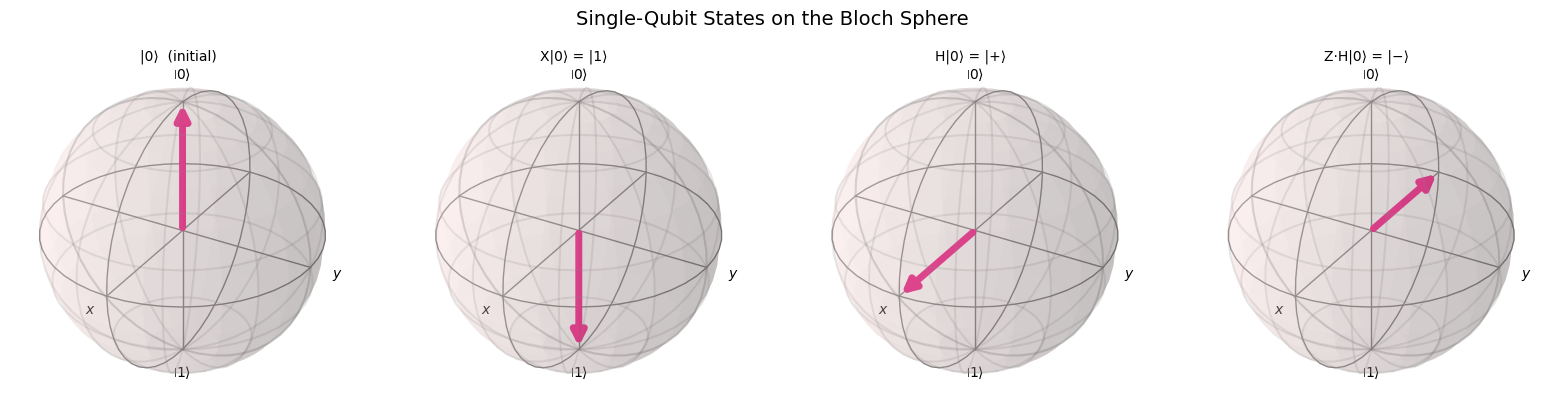

In [16]:
# Demonstrate basic single-qubit gates and visualize on Bloch sphere
from qiskit.quantum_info import SparsePauliOp

def statevector_to_bloch(sv):
    """Convert a single-qubit Statevector to Bloch vector [x, y, z]."""
    rho = np.outer(sv.data, np.conj(sv.data))
    x = float(np.real(np.trace(rho @ np.array([[0,1],[1,0]]))))
    y = float(np.real(np.trace(rho @ np.array([[0,-1j],[1j,0]]))))
    z = float(np.real(np.trace(rho @ np.array([[1,0],[0,-1]]))))
    return [x, y, z]

states = {
    "|0⟩  (initial)": Statevector.from_label("0"),
    "X|0⟩ = |1⟩": Statevector.from_label("0").evolve(Operator.from_label("X")),
    "H|0⟩ = |+⟩": Statevector.from_label("0").evolve(Operator.from_label("H")),
    "Z·H|0⟩ = |−⟩": Statevector.from_label("0").evolve(Operator.from_label("H")).evolve(Operator.from_label("Z")),
}

fig = plt.figure(figsize=(16, 4))
for idx, (label, sv) in enumerate(states.items()):
    ax = fig.add_subplot(1, 4, idx + 1, projection="3d")
    bloch_vec = statevector_to_bloch(sv)
    plot_bloch_vector(bloch_vec, title=label, ax=ax, font_size=10)

plt.suptitle("Single-Qubit States on the Bloch Sphere", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


H|0⟩ measurement distribution:
  |0⟩: 49.1%    |1⟩: 50.9%


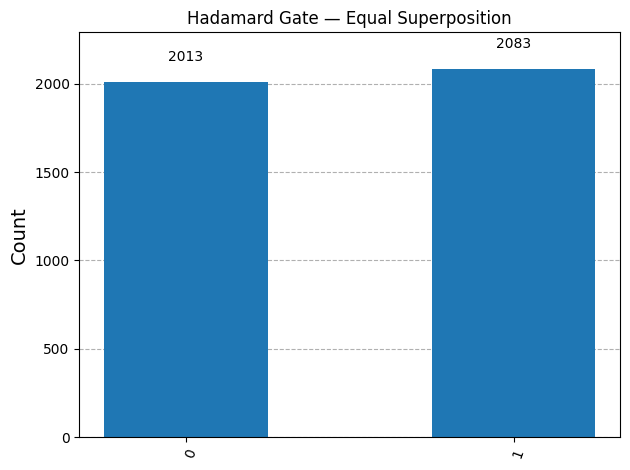

In [17]:
# Measure superposition: H gate puts qubit in equal superposition
qc = QuantumCircuit(1, 1)
qc.h(0)
qc.measure(0, 0)

result = sim.run(qc, shots=SHOTS).result()
counts = result.get_counts()

print("H|0⟩ measurement distribution:")
print(f"  |0⟩: {counts.get('0', 0)/SHOTS:.1%}    |1⟩: {counts.get('1', 0)/SHOTS:.1%}")
plot_histogram(counts, title="Hadamard Gate — Equal Superposition")


---
## 2 — Entanglement & Bell States

The **Bell states** are the four maximally entangled two-qubit states. The canonical Bell pair $|\Phi^+\rangle$ is created with a Hadamard + CNOT:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

When measured, both qubits **always agree** — this is the essence of quantum entanglement.


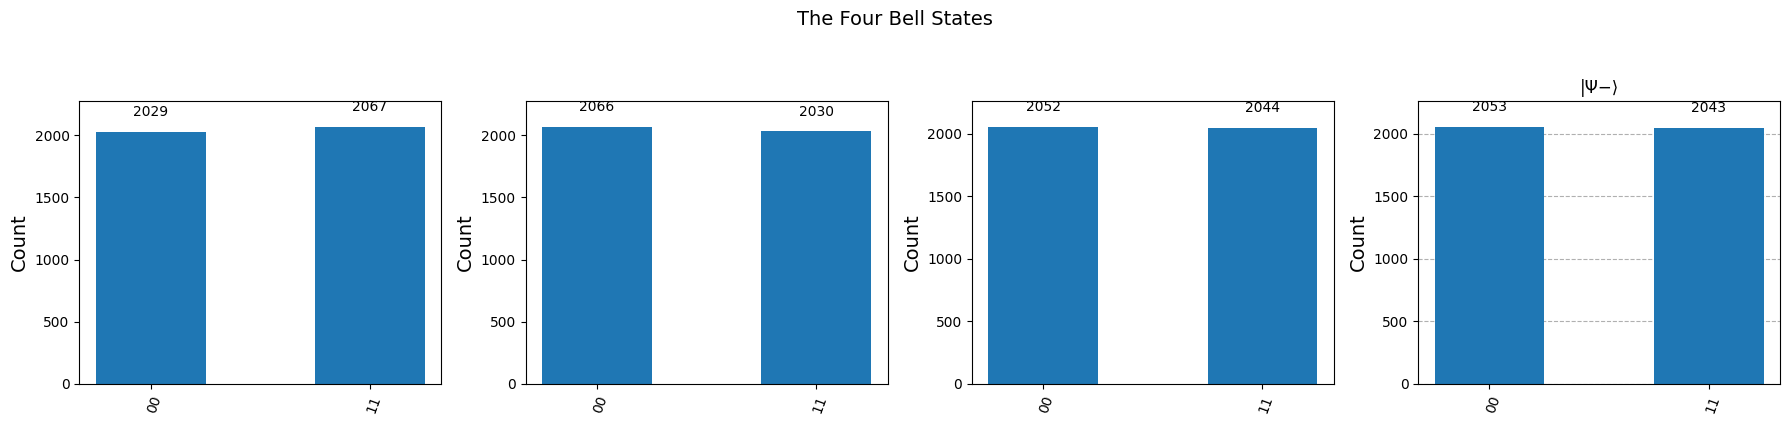

In [18]:
# Build all four Bell states
bell_circuits = {}
bell_labels = {
    "Φ+": [],       # H, CNOT
    "Φ−": ["z"],    # Z on q0, then H, CNOT
    "Ψ+": ["x"],    # X on q0, then H, CNOT
    "Ψ−": ["x","z"] # X+Z on q0, then H, CNOT
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (name, pre_gates) in enumerate(bell_labels.items()):
    qc = QuantumCircuit(2, 2)
    for g in pre_gates:
        if g == "x":
            qc.x(0)
        elif g == "z":
            qc.z(0)
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0, 1], [0, 1])
    
    result = sim.run(qc, shots=SHOTS).result()
    counts = result.get_counts()
    bell_circuits[name] = counts
    
    plot_histogram(counts, ax=axes[idx], title=f"|{name}⟩")

plt.suptitle("The Four Bell States", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


In [19]:
# Let's look at the Bell state circuit in detail
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
qc_bell.measure([0, 1], [0, 1])

print("Bell State |Φ+⟩ Circuit:")
print(qc_bell.draw(output="text"))

# Verify entanglement via statevector (without measurement)
qc_sv = QuantumCircuit(2)
qc_sv.h(0)
qc_sv.cx(0, 1)
sv = Statevector(qc_sv)
print(f"\nStatevector: {sv}")
print(f"Probabilities: {sv.probabilities_dict()}")


Bell State |Φ+⟩ Circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
Probabilities: {np.str_('00'): np.float64(0.4999999999999999), np.str_('11'): np.float64(0.4999999999999999)}


---
## 3 — Quantum Teleportation

Quantum teleportation transfers the state of one qubit to another using:
- A shared Bell pair (entanglement resource)
- Two classical bits of communication

**Protocol:**
1. Alice and Bob share a Bell pair (qubits 1 & 2).
2. Alice entangles her data qubit (qubit 0) with her half of the Bell pair.
3. Alice measures both her qubits and sends the 2 classical bits to Bob.
4. Bob applies corrections based on Alice's measurement results.

The data qubit's state is "teleported" to Bob — no physical qubit moves!


In [20]:
def teleportation_circuit(state_prep_gate="h"):
    """
    Build a quantum teleportation circuit.
    state_prep_gate: gate to apply to qubit 0 to create the state to teleport.
    """
    qr = QuantumRegister(3, "q")
    cr = ClassicalRegister(2, "c")  # Alice's measurement results
    cr_verify = ClassicalRegister(1, "verify")  # Bob's verification measurement
    qc = QuantumCircuit(qr, cr, cr_verify)
    
    # Step 0: Prepare the state to teleport on qubit 0
    if state_prep_gate == "h":
        qc.h(0)
    elif state_prep_gate == "x":
        qc.x(0)
    elif state_prep_gate == "rx":
        qc.rx(np.pi / 4, 0)
    qc.barrier(label="prep")
    
    # Step 1: Create Bell pair between qubits 1 and 2
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier(label="bell")
    
    # Step 2: Alice's operations (entangle q0 with q1, then measure)
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier(label="alice")
    qc.measure(0, cr[0])
    qc.measure(1, cr[1])
    
    # Step 3: Bob's corrections (conditional on Alice's measurements)
    qc.barrier(label="bob")
    with qc.if_test((cr[1], 1)):
        qc.x(2)
    with qc.if_test((cr[0], 1)):
        qc.z(2)
    
    # Verify by measuring Bob's qubit
    qc.measure(2, cr_verify[0])
    
    return qc


# Teleport the |+⟩ state (H|0⟩)
qc_tp = teleportation_circuit("h")
print("Teleportation Circuit (teleporting |+⟩ state):")
print(qc_tp.draw(output="text", fold=120))


Teleportation Circuit (teleporting |+⟩ state):
          ┌───┐ prep            bell      ┌───┐ alice ┌─┐    bob                                                     »
     q_0: ┤ H ├──░───────────────░─────■──┤ H ├───░───┤M├─────░──────────────────────────────────────────────────────»
          └───┘  ░   ┌───┐       ░   ┌─┴─┐└───┘   ░   └╥┘┌─┐  ░                                                      »
     q_1: ───────░───┤ H ├──■────░───┤ X ├────────░────╫─┤M├──░──────────────────────────────────────────────────────»
                 ░   └───┘┌─┴─┐  ░   └───┘        ░    ║ └╥┘  ░    ┌──────  ┌───┐ ───────┐   ┌──────  ┌───┐ ───────┐ »
     q_2: ───────░────────┤ X ├──░────────────────░────╫──╫───░────┤ If-0  ─┤ X ├  End-0 ├───┤ If-0  ─┤ Z ├  End-0 ├─»
                 ░        └───┘  ░                ░    ║  ║   ░    └──╥───  └───┘ ───────┘   └──╥───  └───┘ ───────┘ »
                                                       ║  ║      ┌────╨────┐               ┌────╨────┐               »
 

In [21]:
# Run teleportation and verify
# If we teleport |+⟩, Bob should measure |0⟩ and |1⟩ with ~equal probability

result = sim.run(qc_tp, shots=SHOTS).result()
counts = result.get_counts()

# Extract just Bob's measurement (the 'verify' bit)
bob_counts = {"0": 0, "1": 0}
for bitstring, count in counts.items():
    bob_bit = bitstring.split()[0]  # leftmost register = verify
    bob_counts[bob_bit] += count

print("Teleportation of |+⟩ state — Bob's qubit measurement:")
for k, v in sorted(bob_counts.items()):
    print(f"  |{k}⟩: {v/SHOTS:.1%}")

fig = plot_histogram(bob_counts, title="Teleported |+⟩ State — Bob's Measurement")
plt.show()
print("\n✓ Near 50/50 split confirms successful teleportation of superposition!")


Teleportation of |+⟩ state — Bob's qubit measurement:
  |0⟩: 50.5%
  |1⟩: 49.5%

✓ Near 50/50 split confirms successful teleportation of superposition!


---
## 4 — Deutsch–Jozsa Algorithm

The Deutsch–Jozsa algorithm determines whether a black-box function $f: \{0,1\}^n \to \{0,1\}$ is **constant** (same output for all inputs) or **balanced** (outputs 0 for exactly half the inputs and 1 for the other half).

Classically this requires up to $2^{n-1}+1$ queries. Quantum: **one query**.

We'll implement the $n=3$ case with different oracles.


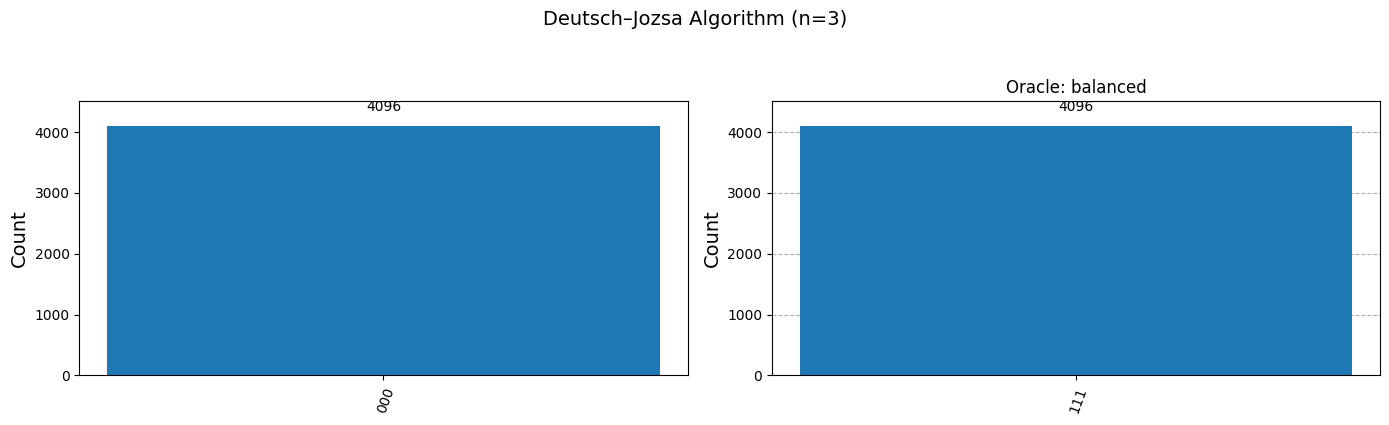

Interpretation:
  • Constant oracle → all measurements are |000⟩
  • Balanced oracle → NEVER measures |000⟩
  ⇒ One query distinguishes constant from balanced!


In [22]:
def deutsch_jozsa(n, oracle_type="balanced"):
    """
    Deutsch-Jozsa algorithm for n-bit input.
    oracle_type: 'constant_0', 'constant_1', or 'balanced'
    """
    qc = QuantumCircuit(n + 1, n)
    
    # Initialize: input qubits in |+⟩, output qubit in |−⟩
    qc.x(n)               # output qubit to |1⟩
    qc.h(range(n + 1))    # all qubits through H
    qc.barrier(label="init")
    
    # Oracle
    if oracle_type == "constant_0":
        pass  # f(x) = 0 for all x → identity
    elif oracle_type == "constant_1":
        qc.x(n)  # f(x) = 1 for all x → flip output
    elif oracle_type == "balanced":
        # f(x) = x_0 XOR x_1 (balanced for n >= 2)
        for i in range(n):
            qc.cx(i, n)
    
    qc.barrier(label="oracle")
    
    # Apply H to input qubits and measure
    qc.h(range(n))
    qc.measure(range(n), range(n))
    
    return qc


# Test with n=3
n = 3
results_dj = {}

for oracle in ["constant_0", "balanced"]:
    qc = deutsch_jozsa(n, oracle)
    result = sim.run(qc, shots=SHOTS).result()
    counts = result.get_counts()
    results_dj[oracle] = counts

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (oracle, counts) in zip(axes, results_dj.items()):
    plot_histogram(counts, ax=ax, title=f"Oracle: {oracle}")

plt.suptitle("Deutsch–Jozsa Algorithm (n=3)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  • Constant oracle → all measurements are |000⟩")
print("  • Balanced oracle → NEVER measures |000⟩")
print("  ⇒ One query distinguishes constant from balanced!")


---
## 5 — Grover's Search Algorithm

Grover's algorithm finds a marked item in an unsorted database of $N$ items with $O(\sqrt{N})$ queries, compared to $O(N)$ classically.

**Key components:**
1. **Oracle** — flips the phase of the target state
2. **Diffusion operator** — amplifies the amplitude of the marked state

We search a 3-qubit space ($N = 8$) for the target state $|101\rangle$.


In [23]:
def grover_oracle(qc, target, n):
    """Phase oracle that flips the sign of |target⟩."""
    # Flip qubits where target bit is 0
    for i in range(n):
        if target[n - 1 - i] == "0":
            qc.x(i)
    # Multi-controlled Z (= H·MCX·H on last qubit)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    # Undo flips
    for i in range(n):
        if target[n - 1 - i] == "0":
            qc.x(i)


def grover_diffusion(qc, n):
    """Diffusion (inversion about the mean) operator."""
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))


def grover_search(target, n, num_iterations=None):
    """Full Grover circuit for n qubits searching for |target⟩."""
    if num_iterations is None:
        num_iterations = int(np.round(np.pi / 4 * np.sqrt(2**n)))
    
    qc = QuantumCircuit(n, n)
    
    # Initialize uniform superposition
    qc.h(range(n))
    
    # Apply Grover iterations
    for i in range(num_iterations):
        qc.barrier(label=f"iter {i+1}")
        grover_oracle(qc, target, n)
        grover_diffusion(qc, n)
    
    qc.measure(range(n), range(n))
    return qc


# Search for |101⟩ in a 3-qubit space
target = "101"
n_qubits = 3
optimal_iters = int(np.round(np.pi / 4 * np.sqrt(2**n_qubits)))

qc_grover = grover_search(target, n_qubits)
print(f"Grover's Search for |{target}⟩  (n={n_qubits}, iterations={optimal_iters})")
print(qc_grover.draw(output="text", fold=100))


Grover's Search for |101⟩  (n=3, iterations=2)
     ┌───┐ iter 1           ┌───┐┌───┐               ┌───┐┌───┐      iter 2           ┌───┐┌───┐»
q_0: ┤ H ├───░───────────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────░───────────■──┤ H ├┤ X ├»
     ├───┤   ░    ┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤        ░    ┌───┐  │  ├───┤├───┤»
q_1: ┤ H ├───░────┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├────────░────┤ X ├──■──┤ X ├┤ H ├»
     ├───┤   ░    ├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐   ░    ├───┤┌─┴─┐├───┤├───┤»
q_2: ┤ H ├───░────┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├───░────┤ H ├┤ X ├┤ H ├┤ H ├»
     └───┘   ░    └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘   ░    └───┘└───┘└───┘└───┘»
c: 3/═══════════════════════════════════════════════════════════════════════════════════════════»
                                                                                                »
«                    ┌───┐┌───┐     ┌─┐      
«q_0: ────────────■──┤ X 

In [24]:
# Run Grover's algorithm and visualize
result = sim.run(qc_grover, shots=SHOTS).result()
counts = result.get_counts()

print(f"Target: |{target}⟩")
print(f"Measurement results ({SHOTS} shots):")
for state in sorted(counts, key=counts.get, reverse=True):
    pct = counts[state] / SHOTS
    bar = "█" * int(pct * 40)
    marker = " ← TARGET" if state == target else ""
    print(f"  |{state}⟩: {counts[state]:4d} ({pct:.1%}) {bar}{marker}")

fig = plot_histogram(counts, title=f"Grover's Search — Target |{target}⟩")
plt.show()
print(f"\n✓ Target state |{target}⟩ found with {counts.get(target, 0)/SHOTS:.1%} probability!")


Target: |101⟩
Measurement results (4096 shots):
  |101⟩: 3878 (94.7%) █████████████████████████████████████ ← TARGET
  |110⟩:   37 (0.9%) 
  |001⟩:   36 (0.9%) 
  |100⟩:   33 (0.8%) 
  |011⟩:   30 (0.7%) 
  |010⟩:   30 (0.7%) 
  |111⟩:   28 (0.7%) 
  |000⟩:   24 (0.6%) 

✓ Target state |101⟩ found with 94.7% probability!


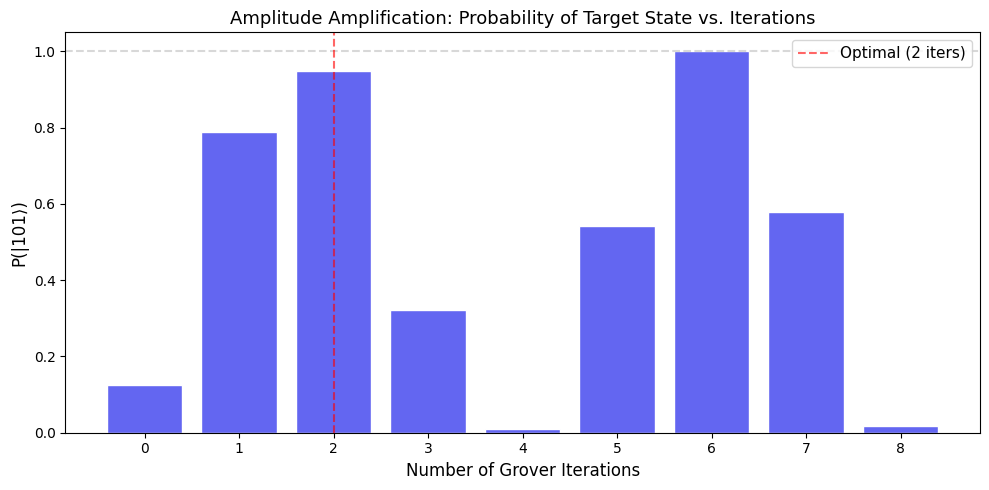

Note: probability oscillates — too many iterations DECREASES success probability!


In [25]:
# Visualize amplitude amplification over iterations
n_qubits = 3
target = "101"

probs_over_iters = []
max_iters = 8

for k in range(max_iters + 1):
    if k == 0:
        # Uniform superposition (0 iterations)
        probs_over_iters.append(1 / 2**n_qubits)
    else:
        qc = grover_search(target, n_qubits, num_iterations=k)
        result = sim.run(qc, shots=SHOTS).result()
        counts = result.get_counts()
        probs_over_iters.append(counts.get(target, 0) / SHOTS)

plt.figure(figsize=(10, 5))
plt.bar(range(max_iters + 1), probs_over_iters, color="#6366f1", edgecolor="white")
plt.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
optimal = int(np.round(np.pi / 4 * np.sqrt(2**n_qubits)))
plt.axvline(x=optimal, color="red", linestyle="--", alpha=0.6, label=f"Optimal ({optimal} iters)")
plt.xlabel("Number of Grover Iterations", fontsize=12)
plt.ylabel(f"P(|{target}⟩)", fontsize=12)
plt.title("Amplitude Amplification: Probability of Target State vs. Iterations", fontsize=13)
plt.xticks(range(max_iters + 1))
plt.ylim(0, 1.05)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Note: probability oscillates — too many iterations DECREASES success probability!")


---
## 6 — Simulating Quantum Noise

Real quantum hardware is noisy. Qiskit Aer lets us model realistic noise channels:

- **Depolarizing noise** — random Pauli errors with some probability
- **Bit-flip / Phase-flip** — specific error types
- **Thermal relaxation** — models T1/T2 decoherence

We'll compare ideal vs. noisy simulation of a Bell state.


In [26]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Build a simple noise model
noise_model = NoiseModel()

# Depolarizing error: 1% on single-qubit gates, 5% on two-qubit gates
error_1q = depolarizing_error(0.01, 1)
error_2q = depolarizing_error(0.05, 2)

noise_model.add_all_qubit_quantum_error(error_1q, ["h", "x", "z", "s", "t"])
noise_model.add_all_qubit_quantum_error(error_2q, ["cx"])

print("Noise model:")
print(f"  Single-qubit depolarizing: p = 0.01")
print(f"  Two-qubit depolarizing:    p = 0.05")
print(noise_model)


Noise model:
  Single-qubit depolarizing: p = 0.01
  Two-qubit depolarizing:    p = 0.05
NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 's', 'sx', 't', 'x', 'z']
  Instructions with noise: ['t', 's', 'x', 'h', 'z', 'cx']
  All-qubits errors: ['h', 'x', 'z', 's', 't', 'cx']


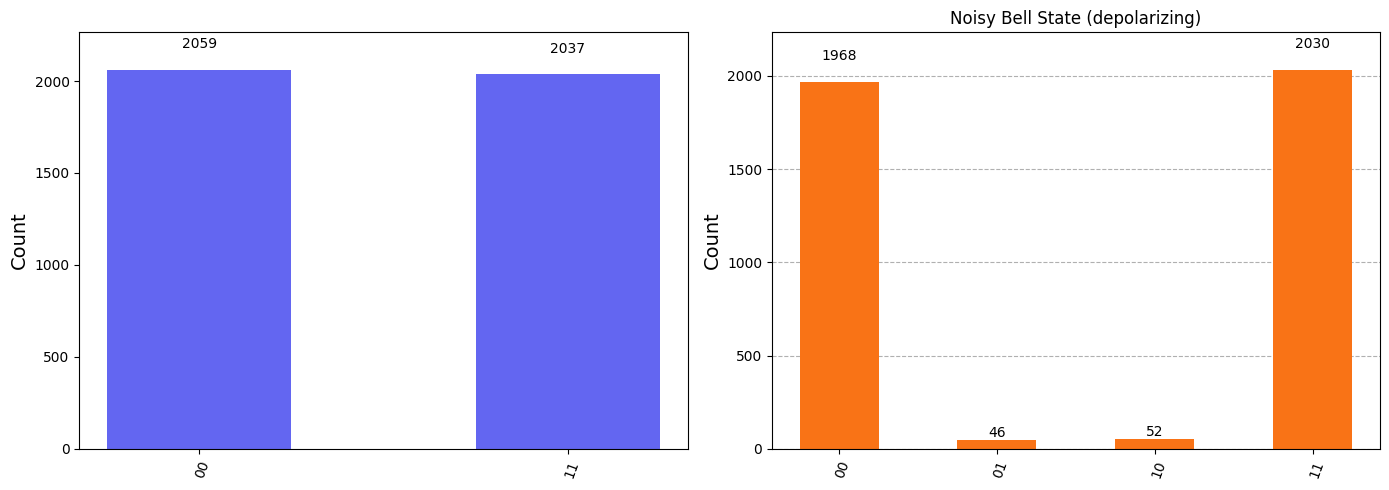


Classical fidelity (ideal vs noisy): 0.9760
Noise introduces |01⟩ and |10⟩ outcomes that are impossible in ideal Bell states.


In [27]:
# Compare ideal vs noisy Bell state
qc_bell = QuantumCircuit(2, 2)
qc_bell.h(0)
qc_bell.cx(0, 1)
qc_bell.measure([0, 1], [0, 1])

# Ideal simulation
result_ideal = sim.run(qc_bell, shots=SHOTS).result()
counts_ideal = result_ideal.get_counts()

# Noisy simulation
noisy_sim = AerSimulator(noise_model=noise_model)
result_noisy = noisy_sim.run(qc_bell, shots=SHOTS).result()
counts_noisy = result_noisy.get_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

plot_histogram(counts_ideal, ax=ax1, title="Ideal Bell State", color="#6366f1")
plot_histogram(counts_noisy, ax=ax2, title="Noisy Bell State (depolarizing)", color="#f97316")

plt.tight_layout()
plt.show()

# Compute fidelity loss
ideal_probs = {k: v/SHOTS for k, v in counts_ideal.items()}
noisy_probs = {k: v/SHOTS for k, v in counts_noisy.items()}

all_states = set(ideal_probs) | set(noisy_probs)
fidelity = sum(
    np.sqrt(ideal_probs.get(s, 0) * noisy_probs.get(s, 0))
    for s in all_states
) ** 2

print(f"\nClassical fidelity (ideal vs noisy): {fidelity:.4f}")
print("Noise introduces |01⟩ and |10⟩ outcomes that are impossible in ideal Bell states.")


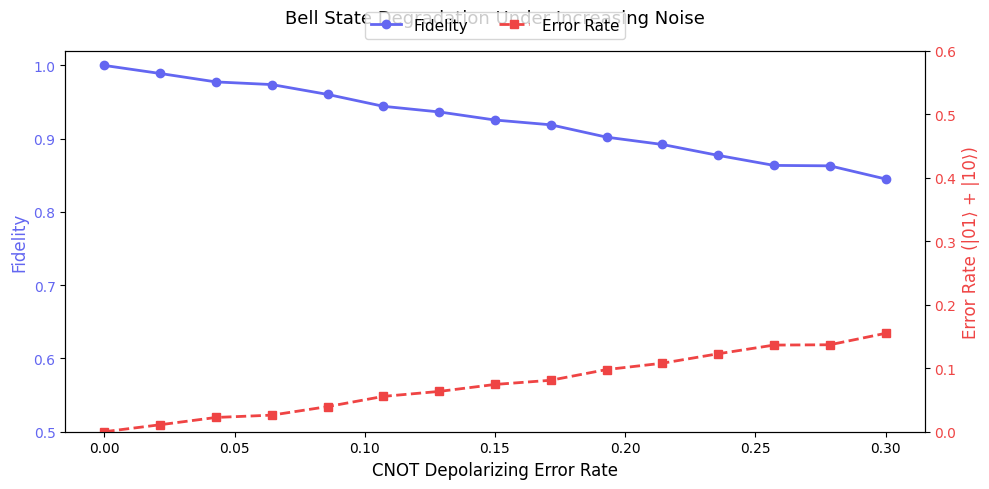

As noise increases, entanglement degrades — error states appear and fidelity drops.


In [28]:
# Sweep noise strength to see degradation
noise_levels = np.linspace(0, 0.3, 15)
fidelities = []
error_rates = []  # fraction of "wrong" outcomes (|01⟩ + |10⟩)

for p in noise_levels:
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p/5, 1), ["h"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p, 2), ["cx"])
    
    noisy = AerSimulator(noise_model=nm)
    result = noisy.run(qc_bell, shots=SHOTS).result()
    counts = result.get_counts()
    
    # Error rate = P(|01⟩) + P(|10⟩)
    errors = counts.get("01", 0) + counts.get("10", 0)
    error_rates.append(errors / SHOTS)
    
    # Classical fidelity with ideal
    noisy_probs = {k: v/SHOTS for k, v in counts.items()}
    f = sum(np.sqrt(ideal_probs.get(s, 0) * noisy_probs.get(s, 0)) for s in set(ideal_probs) | set(noisy_probs)) ** 2
    fidelities.append(f)

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = "#6366f1"
color2 = "#ef4444"

ax1.plot(noise_levels, fidelities, "o-", color=color1, label="Fidelity", linewidth=2)
ax1.set_xlabel("CNOT Depolarizing Error Rate", fontsize=12)
ax1.set_ylabel("Fidelity", fontsize=12, color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim(0.5, 1.02)

ax2 = ax1.twinx()
ax2.plot(noise_levels, error_rates, "s--", color=color2, label="Error Rate", linewidth=2)
ax2.set_ylabel("Error Rate (|01⟩ + |10⟩)", fontsize=12, color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0, 0.6)

fig.legend(loc="upper center", bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=11)
plt.title("Bell State Degradation Under Increasing Noise", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

print("As noise increases, entanglement degrades — error states appear and fidelity drops.")


---
## Summary

| Experiment | Key Takeaway |
|-----------|-------------|
| **Single-qubit gates** | Rotations on the Bloch sphere; H creates superposition |
| **Bell states** | H + CNOT creates maximal entanglement |
| **Teleportation** | Transfer quantum state using entanglement + 2 classical bits |
| **Deutsch–Jozsa** | Exponential speedup: 1 query vs $2^{n-1}+1$ |
| **Grover's search** | Quadratic speedup: $O(\sqrt{N})$ vs $O(N)$ |
| **Noise simulation** | Real hardware has errors; noise models help predict performance |

### Next Steps
- Try modifying the Grover target or increasing the number of qubits
- Explore the **Quantum Fourier Transform** and **Shor's algorithm**
- Run circuits on real IBM quantum hardware via `qiskit-ibm-runtime`
- Study **error correction** codes (e.g., the surface code)

---
*Built with [Qiskit](https://qiskit.org/) — IBM's open-source quantum computing SDK*
